# 🌳 Árbol de Decisión — Regresión (imdb_rating)

In [1]:
#  CELDA 1: Imports + estilo + ETL path
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ── PATH ETL ─────────────────────────────
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
ETL_PATH = os.path.join(BASE_DIR, 'Etl-Proyecto')
if ETL_PATH not in sys.path:
    sys.path.insert(0, ETL_PATH)

# ── ESTILO ─────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style="whitegrid")

In [2]:
# CELDA 2: Ruta de gráficas
RUTA_GRAFICAS = os.path.join('..', 'data', 'graficas', 'arbol_de_decision')
os.makedirs(RUTA_GRAFICAS, exist_ok=True)
print(RUTA_GRAFICAS)

../data/graficas/arbol_de_decision


In [3]:
# CELDA 3: Conexión DB
from scripts.database import SessionLocal
from scripts.models import Pelicula, RegistroPeliculas

In [4]:
# CELDA 4: Carga datos
session = SessionLocal()
rows = session.query(RegistroPeliculas, Pelicula.titulo)\
    .join(Pelicula, Pelicula.id == RegistroPeliculas.pelicula_id).all()
session.close()

df = pd.DataFrame([{
    'titulo': titulo,
    'anio': r.anio,
    'genero': r.genero,
    'imdb_rating': r.imdb_rating,
    'duracion': r.duracion
} for r, titulo in rows])

In [5]:
# CELDA 5: Limpieza
df = df.dropna(subset=['imdb_rating','duracion','anio'])

In [6]:
# CELDA 6: One-hot géneros
dummies = df['genero'].fillna('').str.get_dummies(sep=', ')
dummies.columns = [f'es_{c.lower().replace(" ","_")}' for c in dummies.columns]
df = pd.concat([df, dummies], axis=1)

In [7]:
# CELDA 7: Top géneros
corrs = {c: df[['imdb_rating', c]].corr().iloc[0,1] for c in dummies.columns}
top_generos = sorted(corrs, key=corrs.get, reverse=True)[:5]
top_generos

['es_drama', 'es_war', 'es_crime', 'es_western', 'es_biography']

In [8]:
# CELDA 8: Features (Opción C)
features = ['duracion','anio'] + top_generos
X = df[features].values
y = df['imdb_rating'].values

In [9]:
# CELDA 9: Función evaluar_split
def evaluar_split(X, y, test_size, nombre):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    modelo = DecisionTreeRegressor(random_state=42)
    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    fig, ax = plt.subplots(1,2, figsize=(12,5))

    ax[0].scatter(y_test, y_pred)
    ax[0].plot([5,10],[5,10],'r--')
    ax[0].set_title("Real vs Predicho")

    ax[1].scatter(y_pred, y_test - y_pred)
    ax[1].axhline(0, color='red')
    ax[1].set_title("Residuos")

    plt.savefig(os.path.join(RUTA_GRAFICAS, f"{nombre}.png"), dpi=300, bbox_inches='tight')
    plt.show()

    return r2, rmse, mae, modelo

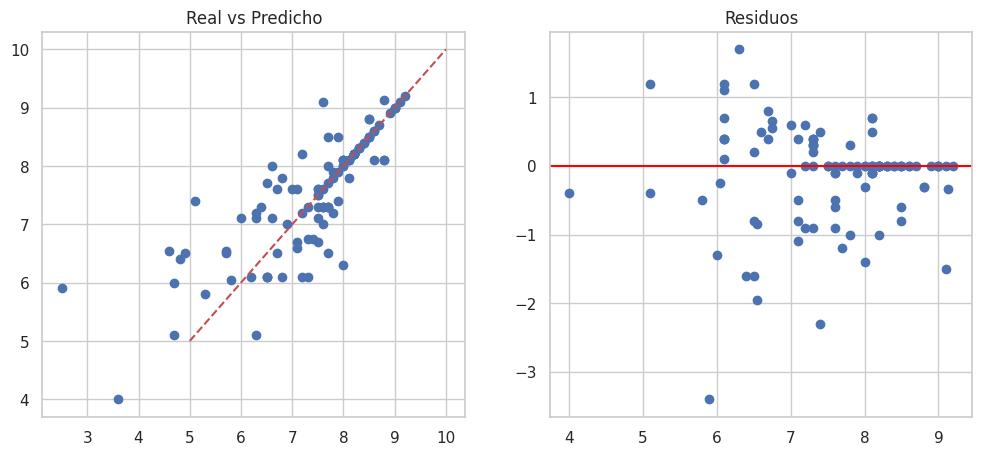

In [10]:
# CELDA 10: Split 80/20
r2_1, rmse_1, mae_1, modelo_1 = evaluar_split(X,y,0.2,"01_split_80_20")

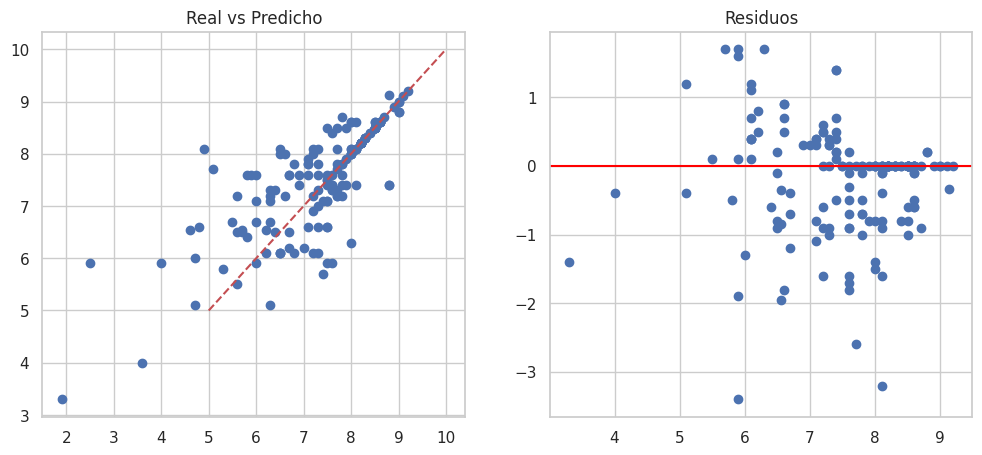

In [11]:
# CELDA 11: Split 70/30
r2_2, rmse_2, mae_2, modelo_2 = evaluar_split(X,y,0.3,"02_split_70_30")

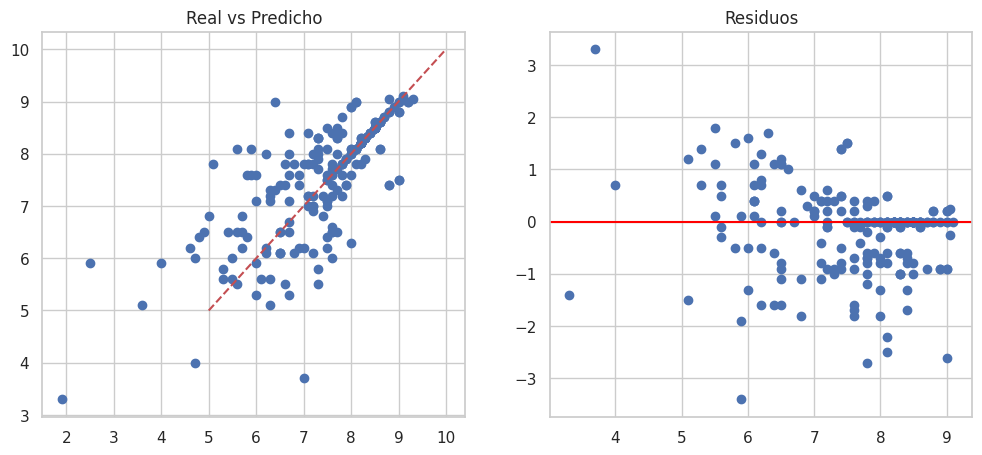

In [12]:
# CELDA 12: Split 60/40
r2_3, rmse_3, mae_3, modelo_3 = evaluar_split(X,y,0.4,"03_split_60_40")

In [13]:
# CELDA 13: Resultados tabla
df_res = pd.DataFrame({
    'Split':['80/20','70/30','60/40'],
    'R2':[r2_1,r2_2,r2_3],
    'RMSE':[rmse_1,rmse_2,rmse_3],
    'MAE':[mae_1,mae_2,mae_3]
})
df_res

,Split,R2,RMSE,MAE
0,80/20,0.627675,0.740688,0.463050
1,70/30,0.552657,0.833927,0.538502
2,60/40,0.492138,0.864588,0.563507


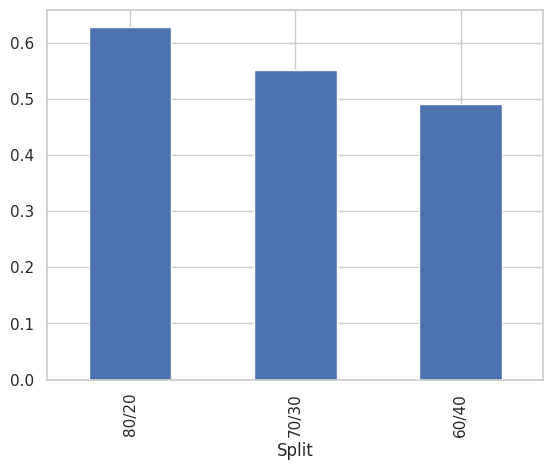

In [14]:
# CELDA 14: Gráfico comparativo
df_res.set_index('Split')['R2'].plot(kind='bar')
plt.savefig(os.path.join(RUTA_GRAFICAS,"04_comparacion.png"), dpi=300, bbox_inches='tight')
plt.show()

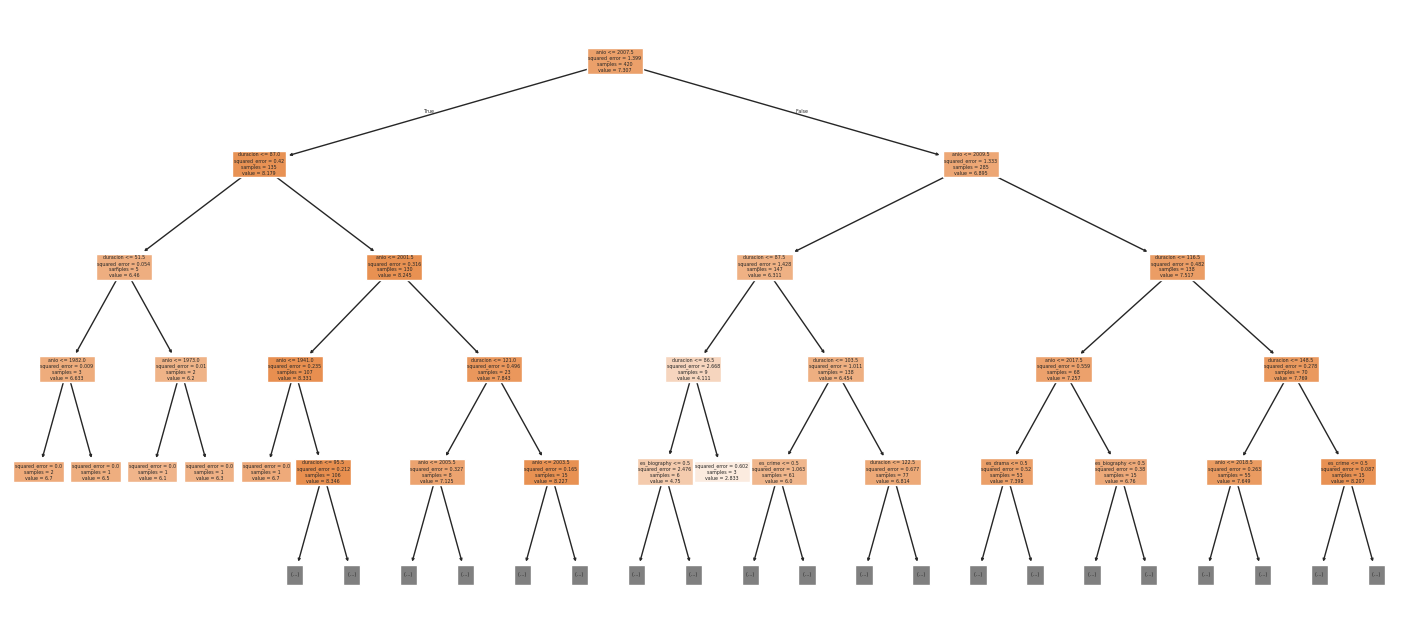

In [15]:
# CELDA 15: Árbol real
fig = plt.figure(figsize=(18,8))
plot_tree(modelo_1, max_depth=4, feature_names=features, filled=True)
plt.savefig(os.path.join(RUTA_GRAFICAS,"05_arbol_real.png"), dpi=300, bbox_inches='tight')
plt.show()

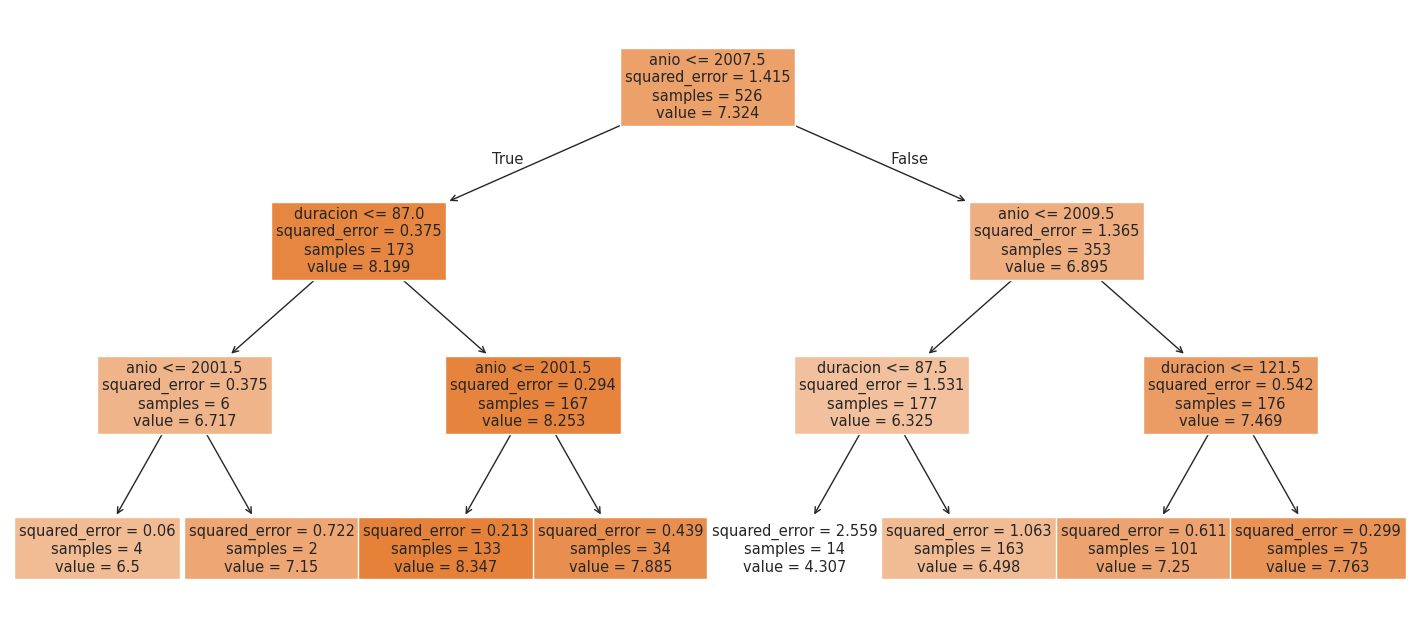

In [16]:
# CELDA 16: Árbol pedagógico
modelo_p = DecisionTreeRegressor(max_depth=3, random_state=42)
modelo_p.fit(X,y)

fig = plt.figure(figsize=(18,8))
plot_tree(modelo_p, feature_names=features, filled=True)
plt.savefig(os.path.join(RUTA_GRAFICAS,"06_arbol_pedagogico.png"), dpi=300, bbox_inches='tight')
plt.show()

In [17]:
# CELDA 17: Profundidad
modelo_1.get_depth()

18

In [18]:
# CELDA 18: Hojas
modelo_1.get_n_leaves()

313

In [19]:
# CELDA 19: Importancia features
pd.Series(modelo_1.feature_importances_, index=features).sort_values()

es_western      0.001543
es_war          0.002085
es_crime        0.018155
es_drama        0.026198
es_biography    0.029230
duracion        0.389675
anio            0.533114
dtype: float64

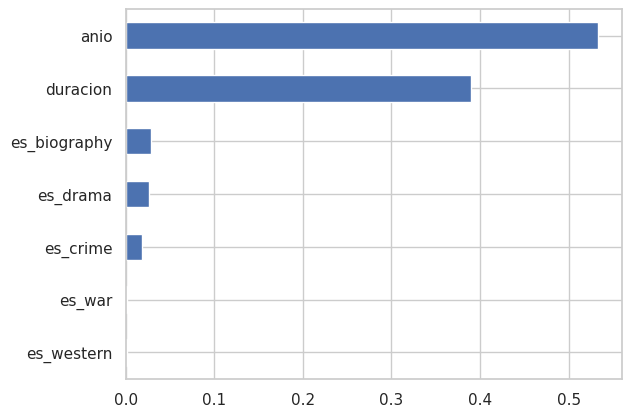

In [20]:
# CELDA 20: Gráfico importancia
pd.Series(modelo_1.feature_importances_, index=features).sort_values().plot(kind='barh')
plt.savefig(os.path.join(RUTA_GRAFICAS,"07_importancia.png"), dpi=300, bbox_inches='tight')
plt.show()

In [21]:
# CELDA 21: Predicción ejemplo
ej = X[0].reshape(1,-1)
modelo_1.predict(ej)

array([8.1])

In [22]:
# CELDA 22: Predicciones batch
modelo_1.predict(X[:5])

array([8.1, 8.7, 9.1, 8.5, 7.9])

In [23]:
# CELDA 23: Error promedio
np.mean(np.abs(y - modelo_1.predict(X))) 


0.15684410646387834

In [24]:
# CELDA 24: Varianza explicada
r2_1

0.627675264989685

In [25]:
# CELDA 25: Comparación splits print
print(df_res)

   Split        R2      RMSE       MAE
0  80/20  0.627675  0.740688  0.463050
1  70/30  0.552657  0.833927  0.538502
2  60/40  0.492138  0.864588  0.563507


In [27]:
# CELDA 26: Predictor interactivo
nueva = [150, 2000] + [1 if g in top_generos else 0 for g in top_generos]
modelo_1.predict([nueva])

array([8.2])

In [28]:
print("Modelo Árbol de Decisión listo")

Modelo Árbol de Decisión listo
